In [1]:
from accelforge import Spec, examples
from pathlib import Path

In [2]:
def get_energy(result):
    """Get total energy in pJ."""
    return float(result.energy())


def get_cycles(result):
    """Get total latency in cycles."""
    return float(result.latency())


def get_component_energy(result, component):
    """Get energy for a specific component."""
    energy = result.energy(per_component=True)
    return float(energy.get(component, 0))

In [8]:
spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU.yaml",
    "../workloads/flash_attention_simple.yaml"
)
results = spec.map_workload_to_arch(disable_fusion=True)



Getting energy, latency, and leak power for components running :   0%|   | 0/27 [00:00<?, ?it/s]

Getting energy, latency, and leak power for components running QK_0:   0%| | 0/27 [00:00<?, ?it/

Getting energy, latency, and leak power for components running max_0:   0%| | 0/27 [00:00<?, ?it

Getting energy, latency, and leak power for components running max_0:   7%| | 2/27 [00:00<00:01,

Getting energy, latency, and leak power for components running exp_0:   7%| | 2/27 [00:00<00:01,

Getting energy, latency, and leak power for components running sum_0:   7%| | 2/27 [00:00<00:01,

Getting energy, latency, and leak power for components running sum_0:  15%|▏| 4/27 [00:00<00:01,

Getting energy, latency, and leak power for components running softmax_0:  15%|▏| 4/27 [00:00<00

Getting energy, latency, and leak power for components running AV_0:  15%|▏| 4/27 [00:00<00:01, 

Getting energy, latency, and leak power for components running AV_0:  22%|▏| 6/27 [00:00<00:01, 

Getting energy, la

Einsum QK_0 has 108 pmapping jobs:
	0	[Q in MainMemory] [K_0 in MainMemory] [QK_0 in GlobalBuffer] T-b  T-e  T-h  T-m  S-reuse_weight2-m  S-reuse_weight1-m  [Q in MxuBuffer] T-m_chunk  [QK_0 in MxuBuffer] T-e  MXU computes QK_0
	1	[Q in MainMemory] [K_0 in MainMemory] [QK_0 in GlobalBuffer] T-b  T-h  T-m  T-m_chunk  S-reuse_weight2-m  S-reuse_weight1-m  [QK_0 in MxuBuffer] T-e  [Q in MxuBuffer] T-m_chunk  MXU computes QK_0
	2	[Q in MainMemory] [K_0 in MainMemory] [K_0 in GlobalBuffer] [QK_0 in GlobalBuffer] T-b  T-e  T-h  T-m  S-reuse_weight2-m  S-reuse_weight1-m  [Q in MxuBuffer] T-m_chunk  [QK_0 in MxuBuffer] T-e  MXU computes QK_0
	3	[Q in MainMemory] [K_0 in MainMemory] [K_0 in GlobalBuffer] [QK_0 in GlobalBuffer] T-b  T-h  T-m  T-m_chunk  S-reuse_weight2-m  S-reuse_weight1-m  [QK_0 in MxuBuffer] T-e  [Q in MxuBuffer] T-m_chunk  MXU computes QK_0
	4	[Q in MainMemory] [K_0 in MainMemory] [QK_0 in GlobalBuffer] T-b  T-e  T-h  T-m_chunk  [K_0 in GlobalBuffer] T-m  S-reuse_weight2-m  S

Compressing pmappings: 100%|███████████████████████████████████| 27/27 [00:00<00:00, 203.29it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|█████████████████████████████████| 92/92 [00:00<00:00, 868.79it/s]


...

Dirty pruning pmappings: 100%|████████████████████████████████| 92/92 [00:00<00:00, 1011.38it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 92 -> 92 (100.00% kept) pmappings


Joining pmappings for exp_0 <--> sum_0 (4/27): 100%|██████████████| 2/2 [00:00<00:00, 74.59it/s]
Joining pmappings for sum_0 <--> softmax_0 (5/27): 100%|█████████| 4/4 [00:00<00:00, 149.60it/s]
Joining pmappings for exp_1 <--> sum_1 (10/27): 100%|████████████| 4/4 [00:00<00:00, 112.71it/s]
Joining pmappings for sum_1 <--> softmax_1 (11/27): 100%|████████| 8/8 [00:00<00:00, 169.14it/s]
Grouping pmappings: 100%|████████████████████████████████████████| 4/4 [00:00<00:00, 151.65it/s]
Joining pmappings for softmax_1 <--> AV_1 (12/27): 100%|█████████| 8/8 [00:00<00:00, 162.85it/s]
Grouping pmappings: 100%|████████████████████████████████████████| 4/4 [00:00<00:00, 156.78it/s]
Joining pmappings for AV_1 <--> AV_accum_1 (13/27): 100%|████████| 8/8 [00:00<00:00, 194.03it/s]
Grouping pmappings: 100%|█████████████████████████████████████████| 2/2 [00:00<00:00, 54.61it/s]
Joining pmappings for AV_accum_1 <--> QK_2 (14/27): 100%|████████| 4/4 [00:00<00:00, 106.06it/s]
Joining pmappings for exp_2 <-

Dirty joining mapping(s) valid & optimal! Returning...


/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:368: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [
/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:368: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


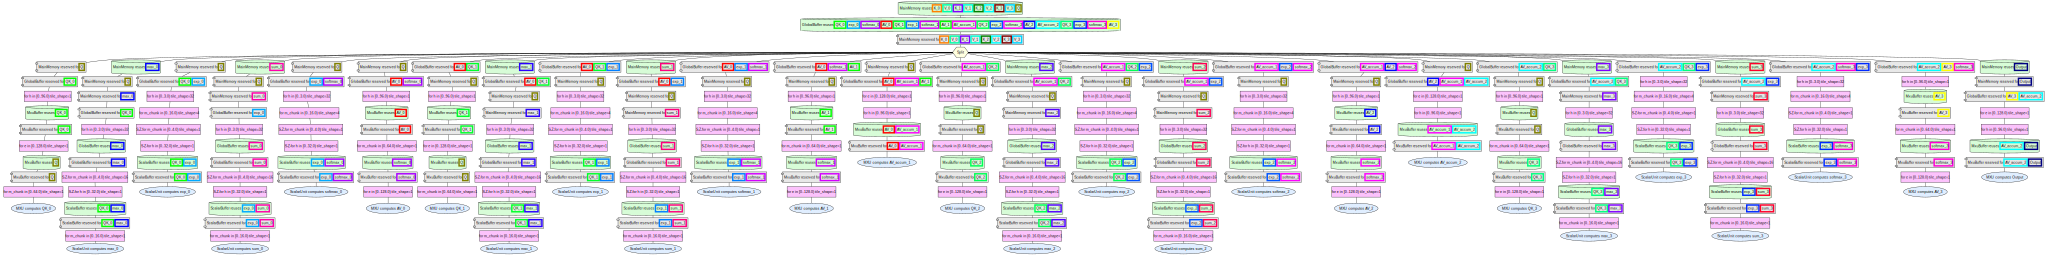

In [9]:
results

In [10]:
print("Total Cycles: ", get_cycles(results))
print("Total Energy: ", get_energy(results))
print("MainMemory: ", get_component_energy(results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(results, 'VpuBuffer'))
print("VPU: ", get_component_energy(results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(results, 'MxuBuffer'))
print("MXU: ", get_component_energy(results, 'MXU'))

Total Cycles:  0.006027044034594198
Total Energy:  0.0004048294750302714
MainMemory:  0.0003573300632834304
GlobalBuffer:  5.810503845586307e-06

ScalarBuffer:  8.524922893551124e-07
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  4.0304836731899546e-05
MXU:  5.3157888e-07
